In [1]:
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

In [1]:
!wget https://storage.googleapis.com/mediapipe-models/image_segmenter/deeplab_v3/float32/latest/deeplab_v3.tflite

--2024-10-22 03:48:00--  https://storage.googleapis.com/mediapipe-models/image_segmenter/deeplab_v3/float32/latest/deeplab_v3.tflite
Resolving storage.googleapis.com (storage.googleapis.com)... 142.250.186.59, 216.58.212.155, 142.250.185.187, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.250.186.59|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2780176 (2.7M) [application/octet-stream]
Saving to: ‘deeplab_v3.tflite’

deeplab_v3.tflite   100%[===================>]   2.65M  5.22MB/s    in 0.5s    

2024-10-22 03:48:01 (5.22 MB/s) - ‘deeplab_v3.tflite’ saved [2780176/2780176]



In [2]:
model_path = './deeplab_v3.tflite'

In [3]:
BaseOptions = mp.tasks.BaseOptions
ImageSegmenter = mp.tasks.vision.ImageSegmenter
ImageSegmenterOptions = mp.tasks.vision.ImageSegmenterOptions
VisionRunningMode = mp.tasks.vision.RunningMode

# Create a image segmenter instance with the image mode:
options = ImageSegmenterOptions(
    base_options=BaseOptions(model_asset_path=model_path),
    running_mode=VisionRunningMode.IMAGE,
    output_category_mask=True)


I0000 00:00:1729561765.856440 48621989 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 88.1), renderer: Apple M2 Max
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1729561765.859848 48622349 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
/Users/hyuk/anaconda3/envs/fastCampus/lib/python3.11/site-packages/mediapipe/tasks/python/vision/image_segmenter.py:158: UserWarning: MessageFactory class is deprecated. Please use GetMessageClass() instead of MessageFactory.GetPrototype. MessageFactory class will be removed after 2024.
  graph_config = self._runner.get_graph_config()


I0000 00:00:1729562181.401961 48621989 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 88.1), renderer: Apple M2 Max
W0000 00:00:1729562181.404691 48635783 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


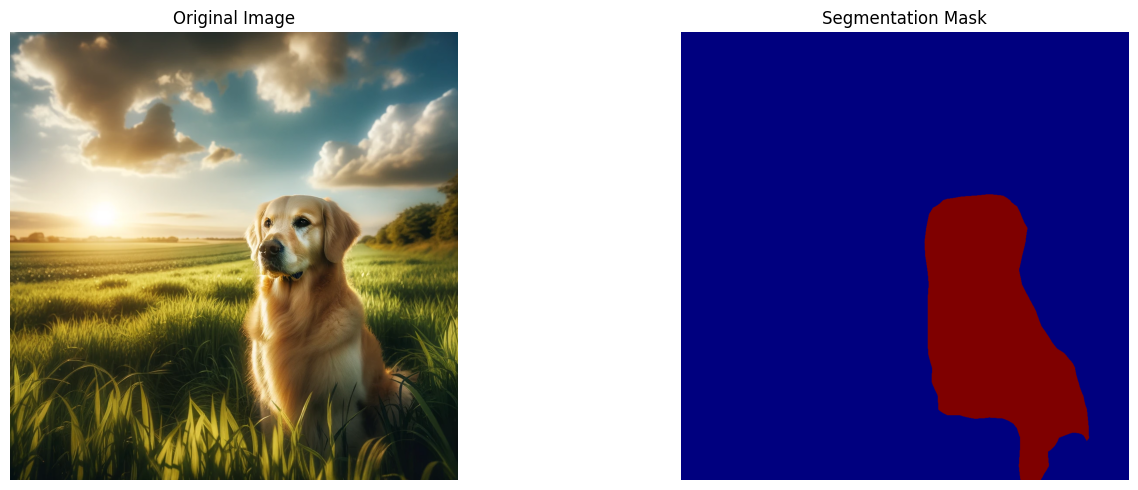

In [9]:
import matplotlib.pyplot as plt
import numpy as np
with ImageSegmenter.create_from_options(options) as segmenter:
    # 1. Load and process image
    mp_image = mp.Image.create_from_file('./dog.png')
    segmentation_result = segmenter.segment(mp_image)
    
    # Convert MediaPipe outputs to numpy arrays
    image_data = mp_image.numpy_view()
    category_mask = segmentation_result.category_mask.numpy_view()
    
    # 2. Prepare visualization
    # Normalize mask values to range [0,1] for colormap
    category_mask_normalized = (category_mask - np.min(category_mask)) / (np.max(category_mask) - np.min(category_mask))
    # Apply colormap to normalized mask
    colored_mask = plt.cm.jet(category_mask_normalized)
    
    # 3. Create visualization
    # Set up the figure
    plt.figure(figsize=(15, 5))
    
    # Original image (left)
    plt.subplot(1, 2, 1)
    plt.imshow(image_data)
    plt.title('Original Image')
    plt.axis('off')
    
    # Segmentation mask (right)
    plt.subplot(1, 2, 2)
    plt.imshow(colored_mask)
    plt.title('Segmentation Mask')
    plt.axis('off')
    
    # Adjust layout and display
    plt.tight_layout()
    plt.show()

